In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


def plotar_espectrograma(caminho_mp3,
                         sr=None,
                         n_fft=2048,
                         hop_length=512,
                         fmax=None,
                         cmap='magma'):
    """
    Lê um arquivo MP3 e plota seu espectrograma.

    Parâmetros
    ----------
    caminho_mp3 : str
        Caminho para o arquivo.
    sr : int ou None
        Taxa de amostragem. None mantém a original.
    n_fft : int
        Número de pontos da FFT.
    hop_length : int
        Espaçamento entre janelas.
    fmax : float ou None
        Frequência máxima exibida (Hz).
    cmap : str
        Mapa de cores do matplotlib.
    """

    # Carrega o áudio em mono para reduzir memória usada
    y, sr = librosa.load(caminho_mp3, sr=sr, mono=True)

    # STFT
    D = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length
    )

    # Magnitude
    S = np.abs(D)

    # Conversão para dB
    S_db = librosa.amplitude_to_db(S, ref=np.max)

    # Figura
    plt.figure(figsize=(15, 6))

    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis='time',
        y_axis='hz',
        cmap=cmap
    )

    if fmax is not None:
        plt.ylim(0, fmax)

    plt.colorbar(label='Intensidade (dB)')
    plt.title('Espectrograma')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Frequência (Hz)')
    plt.xlim(0, 5)  # Limita o eixo x para os primeiros segundos
    plt.tight_layout()
    plt.show()

    return S_db

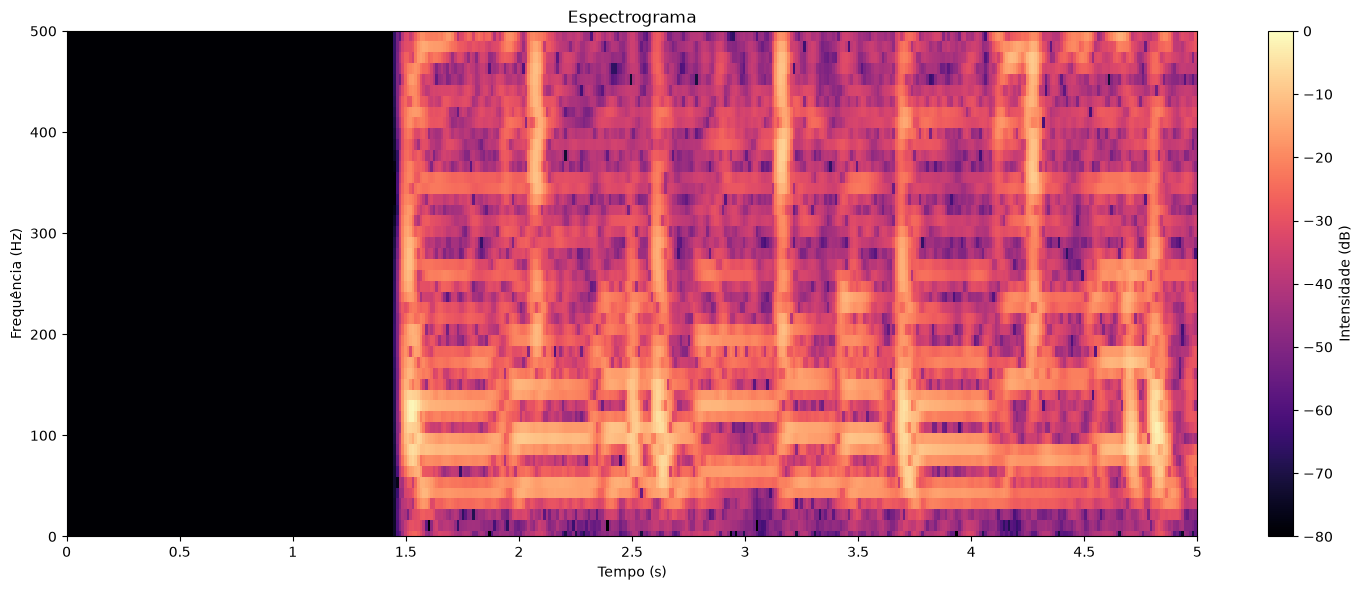

array([[-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       ...,
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.]],
      shape=(2049, 16163), dtype=float32)

In [2]:
plotar_espectrograma(
    "../data/musica-1.mp3",
    sr=None,      # mantém a taxa de amostragem original
    n_fft=4096,   # maior resolução em frequência
    hop_length=512,
    fmax=500   # mostra até 20 kHz
)

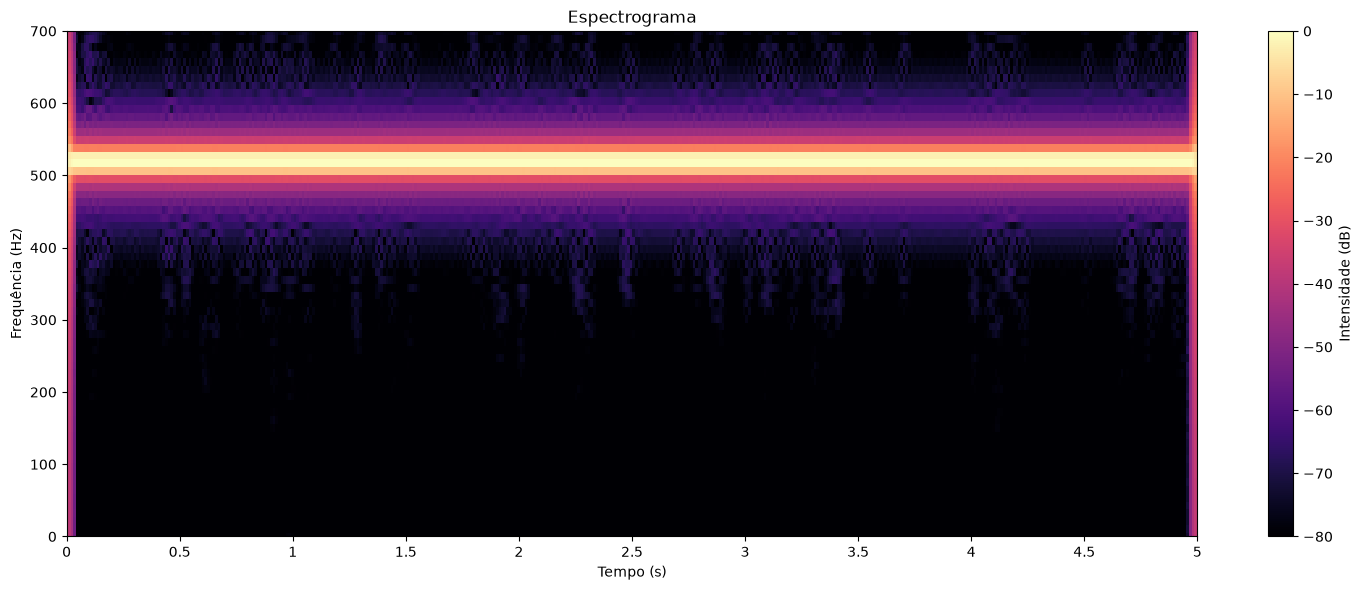

array([[-37.121315, -38.491093, -43.1231  , ..., -49.1279  , -41.105873,
        -37.698593],
       [-37.12382 , -38.502743, -43.158012, ..., -49.090958, -41.11164 ,
        -37.703903],
       [-37.108246, -38.485943, -43.13745 , ..., -49.141064, -41.11474 ,
        -37.697193],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], shape=(2049, 431), dtype=float32)

In [4]:
plotar_espectrograma(
    "../data/musica-2.mp3",
    sr=None,      # mantém a taxa de amostragem original
    n_fft=4096,   # maior resolução em frequência
    hop_length=512,
    fmax=700   # mostra até 20 kHz
)

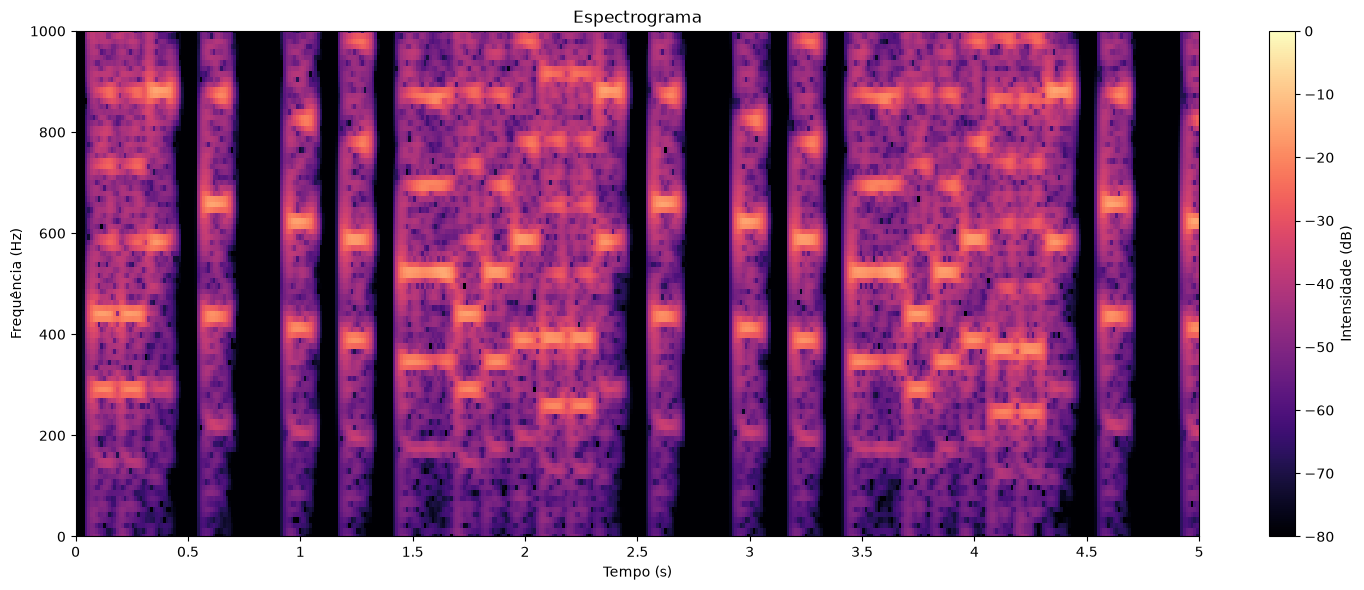

array([[-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       ...,
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.]],
      shape=(2049, 13799), dtype=float32)

In [6]:
plotar_espectrograma(
    "../data/musica-3.mp3",
    sr=None,      # mantém a taxa de amostragem original
    n_fft=4096,   # maior resolução em frequência
    hop_length=512,
    fmax=1000   # mostra até 20 kHz
)

In [ ]:
import numpy as np
from scipy.special import jn_zeros
from scipy.integrate import solve_ivp

R = 0.0422
t = 0.03
sigma = 0.00005
c = np.sqrt(t/sigma)

modes = [(0, 1), (1, 1), (2, 1), (0, 2), (3, 1), (1, 2), (4, 1), (2, 2), (0, 3)]
frequencies = []

for n, m in modes:
    zero = jn_zeros(n, m)[-1]
    f = c * zero / (2 * np.pi * R)
    frequencies.append(float(f"{f:.2f}"))
    print(f"Modo ({n}, {m}): {f:.2f} Hz")

print(f"Frequências dos modos: {frequencies}")





Modo (0, 1): 222.16 Hz
Modo (1, 1): 353.98 Hz
Modo (2, 1): 474.43 Hz
Modo (0, 2): 509.95 Hz
Modo (3, 1): 589.41 Hz
Modo (1, 2): 648.11 Hz
Modo (4, 1): 701.02 Hz
Modo (2, 2): 777.59 Hz
Modo (0, 3): 799.44 Hz
Frequências dos modos: [222.16, 353.98, 474.43, 509.95, 589.41, 648.11, 701.02, 777.59, 799.44]
